<a href="https://colab.research.google.com/github/olkanth/MSCS_634_Lab_6/blob/main/MSCS_634_Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Laxmi Kanth Oruganti
### MSCS-634 : Advanced Big Data and Data Mining
### Lab 6: Association Rule Mining with Apriori and FP-Growth

## Step 1: Data Preparation
- Select a publicly available transactional dataset such as:
  - Book-Crossing Dataset (Kaggle)
- Load the dataset and apply necessary data cleaning steps to ensure the data is ready for mining.
- Ensure that the dataset has item-level transaction records (e.g., product IDs or names) for compatibility with Apriori and FP-Growth algorithms.  
- Create visualizations to explore the dataset and highlight important characteristics (e.g., Seaborn's barplot to show the most frequently occurring items in the dataset, Seaborn's heatmap to visualize item co-occurrence and highlight strong associations between items).

In [4]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [5]:
# Upload dataset to colab space.
from google.colab import files

uploaded = files.upload()
uploaded

Saving Users.csv to Users.csv


{'Users.csv': b'User-ID;Age\n1;\n2;18\n3;\n4;17\n5;\n6;61\n7;\n8;\n9;\n10;26\n11;14\n12;\n13;26\n14;\n15;\n16;\n17;\n18;25\n19;14\n20;19\n21;46\n22;\n23;\n24;19\n25;55\n26;\n27;32\n28;24\n29;19\n30;24\n31;20\n32;\n33;34\n34;\n35;17\n36;24\n37;23\n38;34\n39;\n40;32\n41;14\n42;17\n43;\n44;51\n45;\n46;31\n47;21\n48;\n49;\n50;17\n51;34\n52;\n53;\n54;44\n55;\n56;24\n57;\n58;\n59;23\n60;\n61;30\n62;\n63;57\n64;32\n65;\n66;30\n67;43\n68;\n69;\n70;44\n71;24\n72;34\n73;\n74;30\n75;37\n76;\n77;\n78;18\n79;20\n80;\n81;\n82;\n83;\n84;\n85;41\n86;\n87;\n88;\n89;54\n90;42\n91;\n92;20\n93;50\n94;39\n95;\n96;\n97;\n98;19\n99;42\n100;44\n101;26\n102;\n103;53\n104;47\n105;36\n106;\n107;\n108;\n109;20\n110;\n111;25\n112;32\n113;\n114;57\n115;\n116;\n117;57\n118;28\n119;35\n120;13\n121;\n122;\n123;24\n124;58\n125;49\n126;24\n127;28\n128;\n129;47\n130;\n131;\n132;38\n133;45\n134;\n135;\n136;\n137;\n138;28\n139;35\n140;24\n141;\n142;\n143;26\n144;62\n145;\n146;\n147;\n148;63\n149;\n150;25\n151;\n152;26\n153

In [12]:
# Load the dataset (Books.csv, Ratings.csv, & Users.csv) and apply necessary data cleaning steps to ensure the data is ready for mining.
ratings = pd.read_csv('Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip')
books   = pd.read_csv('Books.csv',   sep=';', encoding='latin-1', on_bad_lines='skip')
users   = pd.read_csv('Users.csv',   sep=';', encoding='latin-1', on_bad_lines='skip',low_memory=False)



print('=' * 55)
print(f'  Ratings  : {ratings.shape[0]:>10,} rows × {ratings.shape[1]} columns')
print(f'  Books    : {books.shape[0]:>10,} rows × {books.shape[1]} columns')
print(f'  Users    : {users.shape[0]:>10,} rows × {users.shape[1]} columns')
print('=' * 55)
print()
print('Ratings — first 5 rows:')
display(ratings.head())

print()
print('Books — first 5 rows:')
print('=' * 55)
display(books.head())

print()
print('Users — first 5 rows:')
print('=' * 55)

display(users.head())


  Ratings  :  1,149,780 rows × 3 columns
  Books    :    271,379 rows × 5 columns
  Users    :    278,859 rows × 2 columns

Ratings — first 5 rows:


,User-ID,ISBN,Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6



Books — first 5 rows:


,ISBN,Title,Author,Year,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company



Users — first 5 rows:


,User-ID,Age
0,1,NaN
1,2,18
2,3,NaN
3,4,17
4,5,NaN


## Perform data quality checks
Look for **missing values, duplicate records, invalid entries, and data-type issues**.

## Validate missing values

In [14]:
# Missing value audit
def audit(df, name):
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    dup_rows    = df.duplicated().sum()
    print(f'\n{'─'*55}')
    print(f'  {name}  ({len(df):,} rows)')
    print(f'{'─'*55}')
    print(f'  Duplicate rows : {dup_rows:,}')
    print(f'  Dtypes         :')
    for col, dtype in df.dtypes.items():
        nulls = null_counts[col]
        pct   = null_pct[col]
        flag  = '  MISSING' if nulls > 0 else ''
        print(f'    {col:<30} {str(dtype):<10}  nulls={nulls:>7,}  ({pct:.1f}%){flag}')

audit(ratings, 'RATINGS')
audit(books,   'BOOKS')
audit(users,   'USERS')


───────────────────────────────────────────────────────
  RATINGS  (1,149,780 rows)
───────────────────────────────────────────────────────
  Duplicate rows : 0
  Dtypes         :
    User-ID                        int64       nulls=      0  (0.0%)
    ISBN                           object      nulls=      0  (0.0%)
    Rating                         int64       nulls=      0  (0.0%)

───────────────────────────────────────────────────────
  BOOKS  (271,379 rows)
───────────────────────────────────────────────────────
  Duplicate rows : 1
  Dtypes         :
    ISBN                           object      nulls=      0  (0.0%)
    Title                          object      nulls=      0  (0.0%)
    Author                         object      nulls=      2  (0.0%)  MISSING
    Year                           int64       nulls=      0  (0.0%)
    Publisher                      object      nulls=      2  (0.0%)  MISSING

───────────────────────────────────────────────────────
  USERS  (278,8

## Validate invalid values

In [18]:
# Invalid entry validation
print('Rating value counts:')
print(ratings['Rating'].value_counts().sort_index().to_frame())
print()
print(f'  Out-of-range ratings (<0 or >10) : {((ratings["Rating"]<0)|(ratings["Rating"]>10)).sum()}')
print()

# Books: invalid publication years
bad_year = books[(books['Year'] == 0) | (books['Year'] > 2026)]
print(f'  Books with invalid Year (0 or >2026): {len(bad_year):,}')

# Users: age cleaning
users['Age'] = pd.to_numeric(users['Age'], errors='coerce')
bad_age = users[(users['Age'] < 5) | (users['Age'] > 100)]
print(f'  Users with abnormal Age (<5 or >100): {len(bad_age):,}')
print(f'  Users with missing Age : {users["Age"].isnull().sum():,}')


Rating value counts:
         count
Rating        
0       716109
1         1770
2         2759
3         5996
4         8904
5        50974
6        36924
7        76457
8       103736
9        67541
10       78610

  Out-of-range ratings (<0 or >10) : 0

  Books with invalid Year (0 or >2026): 4,630
  Users with abnormal Age (<5 or >100): 1,234
  Users with missing Age : 111,708


## Data cleaning

| # | Step | Reason |
|---|------|--------|
| 1 | Drop `Rating = 0` (implicit) | Zero means the user interacted with the book but did not rate it — no genuine preference signal; all explicit ratings 1–10 are retained |
| 2 | Merge book titles from `Books.csv` | Transactions need human-readable item labels, not bare ISBNs |
| 3 | Drop records with missing title | ~49,000 ISBNs in Ratings have no match in Books |
| 4 | Fix invalid publication years | Replace `Year = 0` or `Year > 2024` with `NaN` |
| 5 | Fix implausible user ages | Replace `Age < 5` or `Age > 100` with `NaN` |
| 6 | Filter: users with ≥ 5 rated books | Sparse users produce single-item transactions that cannot yield associations |
| 7 | Remove duplicate (User, Book) pairs | Ensures one-hot encoding is valid (one entry per user per book) |

In [19]:
# ── Cleaning Step 1: drop implicit ratings (Rating = 0) ──────────────────────
df = ratings[ratings['Rating'] > 0].copy()
print(f'[1] Drop implicit (Rating = 0)   : {len(df):>10,} rows  (removed {len(ratings)-len(df):,})')

# ── Cleaning Step 2 & 3: merge book metadata, drop unmatched ISBNs ────────────
book_meta = books[['ISBN','Title','Author','Year','Publisher']].drop_duplicates('ISBN')
df = df.merge(book_meta, on='ISBN', how='left')
before = len(df)
df = df.dropna(subset=['Title'])
print(f'[2+3] Merge titles, drop unmatched: {len(df):>10,} rows  (removed {before-len(df):,})')

# ── Cleaning Step 4: fix invalid years ───────────────────────────────────────
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
bad_year_mask = (df['Year'] == 0) | (df['Year'] > 2024)
df.loc[bad_year_mask, 'Year'] = np.nan
print(f'[4]   Fix invalid Year            :  {bad_year_mask.sum():>9,} values → NaN')

# ── Cleaning Step 5: merge & fix user ages ───────────────────────────────────
users_clean = users.copy()
users_clean['Age'] = pd.to_numeric(users_clean['Age'], errors='coerce')
users_clean.loc[(users_clean['Age']<5)|(users_clean['Age']>100), 'Age'] = np.nan
users_clean['User-ID'] = pd.to_numeric(users_clean['User-ID'], errors='coerce')
df = df.merge(users_clean[['User-ID','Age']], on='User-ID', how='left')
print(f'[5]   Merge user ages              :  done ({df["Age"].isnull().sum():,} missing ages kept as NaN)')

# ── Cleaning Step 6: filter active users (≥ 5 books) ────────────────────────
user_counts = df.groupby('User-ID')['ISBN'].count()
active_users = user_counts[user_counts >= 5].index
before = len(df)
df = df[df['User-ID'].isin(active_users)]
print(f'[6]   Filter users ≥ 5 books      : {len(df):>10,} rows  (removed {before-len(df):,})')

# ── Cleaning Step 7: deduplicate (User, Title) pairs ─────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['User-ID', 'Title'])
print(f'[7]   Deduplicate (User, Book)    : {len(df):>10,} rows  (removed {before-len(df):,})')

print()
print('─' * 55)
print(f'  FINAL CLEAN DATASET')
print(f'  Total interaction records : {len(df):>8,}')
print(f'  Unique users (transactions): {df["User-ID"].nunique():>8,}')
print(f'  Unique book titles (items) : {df["Title"].nunique():>8,}')
print(f'  Unique authors             : {df["Author"].nunique():>8,}')
print(f'  Unique publishers          : {df["Publisher"].nunique():>8,}')
print('─' * 55)

[1] Drop implicit (Rating = 0)   :    433,671 rows  (removed 716,109)
[2+3] Merge titles, drop unmatched:    383,852 rows  (removed 49,819)
[4]   Fix invalid Year            :      5,808 values → NaN
[5]   Merge user ages              :  done (117,058 missing ages kept as NaN)
[6]   Filter users ≥ 5 books      :    302,227 rows  (removed 81,625)
[7]   Deduplicate (User, Book)    :    301,215 rows  (removed 1,012)

───────────────────────────────────────────────────────
  FINAL CLEAN DATASET
  Total interaction records :  301,215
  Unique users (transactions):   12,787
  Unique book titles (items) :  119,351
  Unique authors             :   54,718
  Unique publishers          :   10,163
───────────────────────────────────────────────────────


In [20]:
# ── Preview cleaned dataset ───────────────────────────────────────────────────
print('Cleaned dataset — sample rows:')
display(df[['User-ID','Title','Author','Year','Publisher','Rating','Age']].head(10))
print()
print('Data types after cleaning:')
print(df.dtypes)
print()
print('Remaining missing values:')
print(df.isnull().sum())

Cleaned dataset — sample rows:


,User-ID,Title,Author,Year,Publisher,Rating,Age
4,276747,Little Altars Everywhere,Rebecca Wells,2003.0,HarperTorch,9,25.0
5,276747,Waiting to Exhale,Terry McMillan,1995.0,Pocket,9,25.0
6,276747,Birdsong: A Novel of Love and War,Sebastian Faulks,1997.0,Vintage Books USA,8,25.0
7,276747,How to Deal With Difficult People,Rick Brinkman,1995.0,Careertrack Inc.,7,25.0
8,276747,The Golden Rule of Schmoozing,Aye Jaye,1998.0,Listen & Live Audio,7,25.0
32,276813,La hija del CanÃÂ­bal,Rosa Montero,1998.0,"Espasa Calpe Mexicana, S.A.",8,29.0
33,276813,El Diaro De Bridget Jones,Helen Fielding,1996.0,Lumen Espana,8,29.0
34,276813,Bridget Jones:SobrevivirÃÂ©,Helen Fielding,2000.0,Downtown Book Center Inc,6,29.0
35,276813,La Fiesta De Ralph,Lisa Jewell,NaN,Emece Editores,6,29.0
36,276813,Nadie Es Perfecto (Narrativa Actual),Jane Green,2001.0,Oceano De Mexico,8,29.0



Data types after cleaning:
User-ID        int64
ISBN          object
Rating         int64
Title         object
Author        object
Year         float64
Publisher     object
Age          float64
dtype: object

Remaining missing values:
User-ID          0
ISBN             0
Rating           0
Title            0
Author           2
Year          3899
Publisher        2
Age          82544
dtype: int64


## Build Item-Level Transaction Records

Association Rule Mining requires transactions in the form:  
**Transaction = {item₁, item₂, item₃, …}**

Each transaction here is one **user's set of liked books**. We group by `User-ID` and collect all book titles into a list, then one-hot encode (One-hot encoding is a data preprocessing technique that converts categorical data into binary vectors (0s and 1s) to make them usable for machine learning algorithms.) using `TransactionEncoder` from mlxtend.

In [21]:
# ── Build transaction list ────────────────────────────────────────────────────
transactions = (
    df.groupby('User-ID')['Title']
      .apply(list)
      .tolist()
)

tx_sizes = [len(t) for t in transactions]

print('Transaction format (first 3 users):')
for i, t in enumerate(transactions[:3]):
    print(f'  User {i+1}: {t}')
print()
print('─' * 55)
print(f'  Total transactions         : {len(transactions):>8,}')
print(f'  Total unique items (books) : {df["Title"].nunique():>8,}')
print(f'  Min transaction size       : {min(tx_sizes):>8}')
print(f'  Max transaction size       : {max(tx_sizes):>8}')
print(f'  Mean transaction size      : {np.mean(tx_sizes):>8.2f}')
print(f'  Median transaction size    : {np.median(tx_sizes):>8.0f}')
print('─' * 55)

Transaction format (first 3 users):
  User 1: ['Clara Callan', "Where You'll Find Me: And Other Stories", 'The Middle Stories', 'Jane Doe', 'The Witchfinder (Amos Walker Mystery Series)', 'More Cunning Than Man: A Social History of Rats and Man', 'Goodbye to the Buttermilk Sky']
  User 2: ['Fast Women', 'Female Intelligence', "Pasquale's Nose: Idle Days in an Italian Town", "Prize Stories, 1987: The O'Henry Awards", 'Rich Dad, Poor Dad: What the Rich Teach Their Kids About Money--That the Poor and Middle Class Do Not!', 'The Pillars of the Earth', "McDonald's: Behind the Arches", "Creating Wealth : Retire in Ten Years Using Allen's Seven Principles of Wealth!"]
  User 3: ['Blood Oath', 'The Alibi', 'The Beach House', 'A Kiss Remembered', 'The Short Forever', 'Dead Aim', 'Angels & Demons', 'The Deal']

───────────────────────────────────────────────────────
  Total transactions         :   12,787
  Total unique items (books) :  119,351
  Min transaction size       :        2
  Max trans

In [23]:
# ── One-hot encode into basket DataFrame ─────────────────────────────────────
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array  = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

density = basket_df.values.sum() / (basket_df.shape[0] * basket_df.shape[1])

print(f'One-hot basket matrix shape : {basket_df.shape[0]:,} rows × {basket_df.shape[1]:,} columns')
print(f'Matrix density              : {density*100:.3f}%  (extremely sparse — typical for book data)')
print()
print('Basket DataFrame — first 5 rows, first 6 columns:')
display(basket_df.iloc[:5, :6])

One-hot basket matrix shape : 12,787 rows × 119,351 columns
Matrix density              : 0.020%  (extremely sparse — typical for book data)

Basket DataFrame — first 5 rows, first 6 columns:


,"A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)","Ask Lily (Young Women of Faith: Lily Series, Book 5)",Dark Justice,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Final Fantasy Anthology: Official Strategy Guide (Brady Games),Flight of Fancy: American Heiresses (Zebra Ballad Romance)
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False


## Exploratory Data Analysis & Visualizations

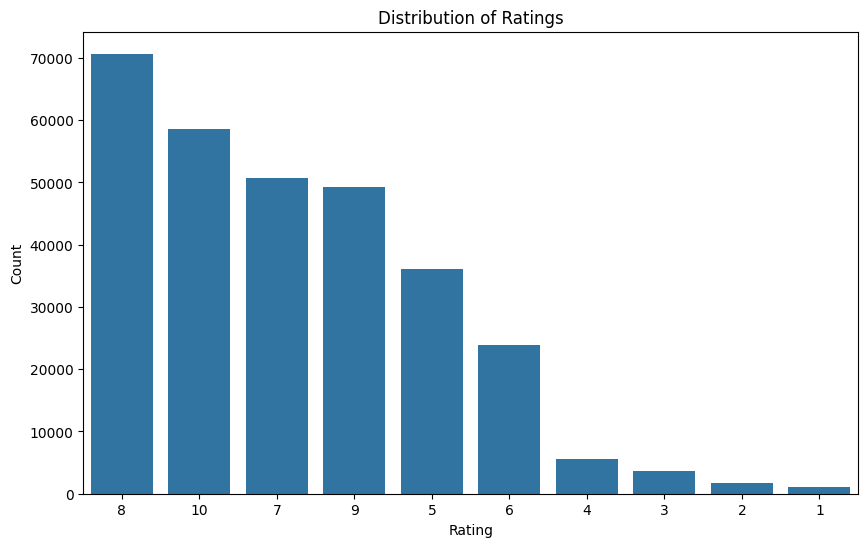


Mean rating  : 7.67
Median rating: 8


In [34]:
# Rating distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating', data=df, order=df['Rating'].value_counts().index)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print()
print("=" * 55)
print(f'Mean rating  : {df["Rating"].mean():.2f}')
print(f'Median rating: {df["Rating"].median():.0f}')


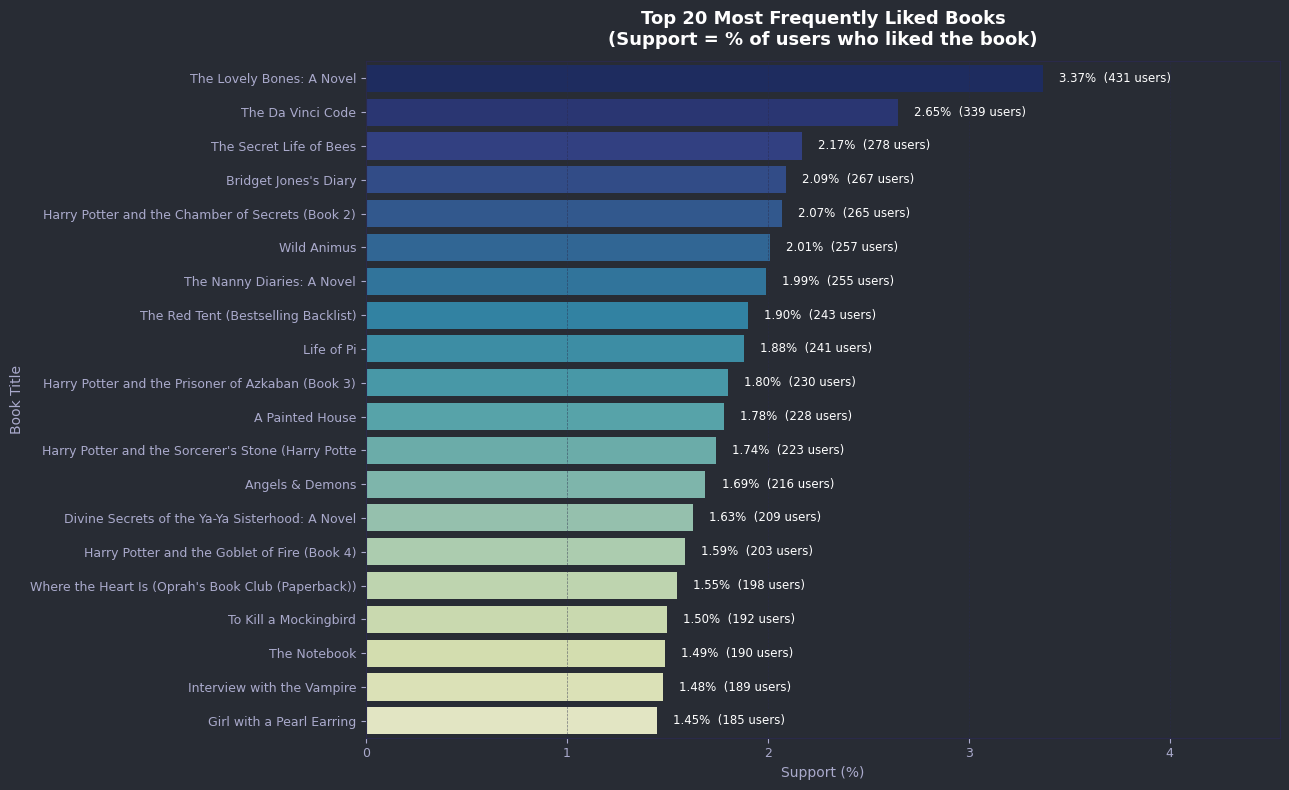

Top 20 books summary table:


,Title,Count,Support (%)
0,The Lovely Bones: A Novel,431,3.37
1,The Da Vinci Code,339,2.65
2,The Secret Life of Bees,278,2.17
3,Bridget Jones's Diary,267,2.09
4,Harry Potter and the Chamber of Secrets (Book 2),265,2.07
5,Wild Animus,257,2.01
6,The Nanny Diaries: A Novel,255,1.99
7,The Red Tent (Bestselling Backlist),243,1.90
8,Life of Pi,241,1.88
9,Harry Potter and the Prisoner of Azkaban (Book 3),230,1.80


In [36]:
# Top 20 Most Frequent Items
item_freq      = df['Title'].value_counts().head(20).reset_index()
item_freq.columns = ['Title', 'Count']
item_freq['Support (%)'] = (item_freq['Count'] / df['User-ID'].nunique() * 100).round(2)
item_freq['Short Title'] = item_freq['Title'].str[:50].str.strip()

fig, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
ax.set_facecolor(BG)

# Seaborn barplot with a gradient palette
grad_palette = sns.color_palette("YlGnBu", n_colors=20)[::-1]
sns.barplot(
    data=item_freq, y='Short Title', x='Support (%)',
    palette=grad_palette, orient='h', ax=ax,
    edgecolor='none', alpha=0.92
)

# Annotate bars
for i, (_, row) in enumerate(item_freq.iterrows()):
    ax.text(row['Support (%)'] + 0.08, i,
            f"{row['Support (%)']:.2f}%  ({row['Count']:,} users)",
            va='center', color='white', fontsize=8.5)

ax.set_title('Top 20 Most Frequently Liked Books\n(Support = % of users who liked the book)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Support (%)', color='#AAAACC', fontsize=10)
ax.set_ylabel('Book Title', color='#AAAACC', fontsize=10)
ax.tick_params(colors='#AAAACC', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#2A2A4A')
ax.grid(axis='x', color='#2A2A4A', linestyle='--', linewidth=0.5, alpha=0.6)
ax.set_xlim(0, item_freq['Support (%)'].max() * 1.35)

plt.tight_layout()
plt.savefig('top20_books_barplot.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

print('Top 20 books summary table:')
display(item_freq[['Title','Count','Support (%)']].reset_index(drop=True))

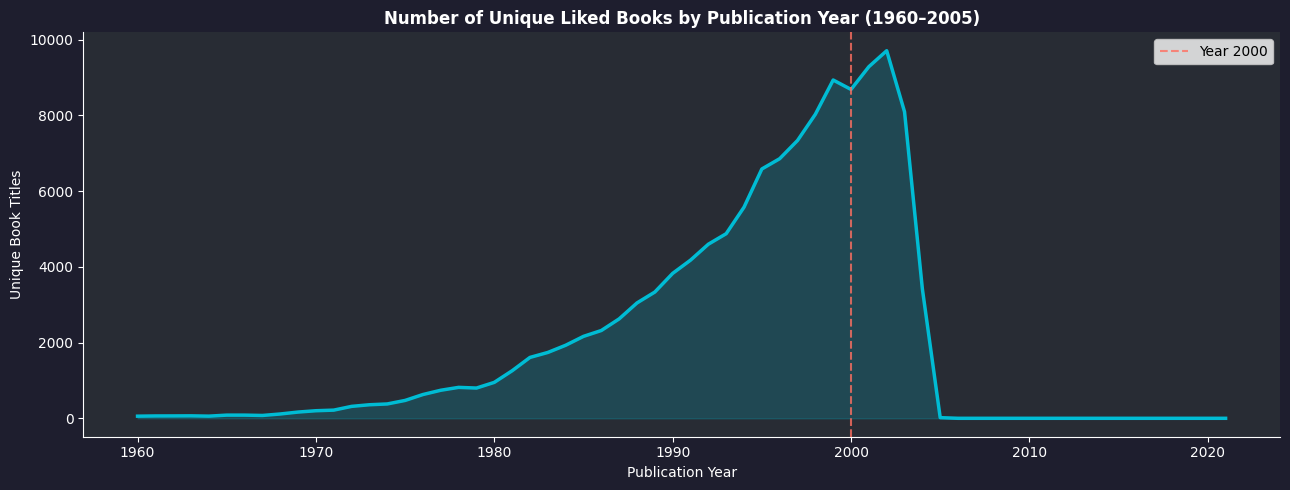

Liked books by decade:
        Unique Titles
Decade               
1960s             831
1970s            4873
1980s           20168
1990s           57772
2000s           37400
2020s               2


In [39]:
# Publication Year Distribution
year_data = df.dropna(subset=['Year']).copy()
year_data['Year'] = year_data['Year'].astype(int)
year_data = year_data[year_data['Year'] >= 1960]  # focus on modern era

year_counts = year_data.groupby('Year')['Title'].nunique().reset_index()
year_counts.columns = ['Year', 'Unique Titles']

fig, ax = plt.subplots(figsize=(13, 5), facecolor='#1E1E2E')
ax.set_facecolor('#1E1E2E')

sns.lineplot(data=year_counts, x='Year', y='Unique Titles',
             color='#00BCD4', linewidth=2.5, ax=ax)
ax.fill_between(year_counts['Year'], year_counts['Unique Titles'],
                alpha=0.2, color='#00BCD4')
ax.axvline(2000, color='#FF6F61', linestyle='--', linewidth=1.5, alpha=0.8,
           label='Year 2000')
style_ax(ax, 'Number of Unique Liked Books by Publication Year (1960–2005)',
         'Publication Year', 'Unique Book Titles')
ax.legend() # Add this line to display the legend

plt.tight_layout()
plt.savefig('year_dist.png', dpi=130, bbox_inches='tight', facecolor='#1E1E2E')
plt.show()
plt.close()

decade = year_data.copy()
decade['Decade'] = (decade['Year'] // 10 * 10).astype(str) + 's'
print('Liked books by decade:')
print(decade.groupby('Decade')['Title'].nunique().rename('Unique Titles').to_frame())